In [ ]:
import pandas as pd, numpy as np, seaborn as sns, xgboost as xgb, os
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn import metrics

# Dataset Verification

In [2]:
df = pd.read_csv('/home/tchowdhury/data/code/CMML-v2/datasets/neutrophil.csv')

In [10]:
df.keys()

Index(['image_path', 'dataset', 'patient_id', 'morphology', 'Age', 'Gender',
       'Haemoglobin', 'MCV', 'White cell count', 'Neutrophil count',
       'Monocyte count', 'Platelet count', 'Blast percentage (PB)', 'LDH',
       'set0', 'set1', 'set2', 'set3', 'set4'],
      dtype='object')

In [5]:
results = pd.DataFrame()

sets = ['set0', 'set1', 'set2', 'set3', 'set4']
for set_name in sets:
    total_patients = df.groupby(set_name)['patient_id'].nunique()
    
    train_test_distribution = df.groupby([set_name, 'patient_id']).size().unstack(fill_value=0).sum(axis=1).reset_index()
    train_count = train_test_distribution[train_test_distribution[set_name] == 'train'][0].sum()
    test_count = train_test_distribution[train_test_distribution[set_name] == 'test'][0].sum()

    train_cmml_count = df[(df[set_name] == 'train') & (df['morphology'] == 0)].shape[0]
    train_normal_count = df[(df[set_name] == 'train') & (df['morphology'] == 1)].shape[0]
    test_cmml_count = df[(df[set_name] == 'test') & (df['morphology'] == 0)].shape[0]
    test_normal_count = df[(df[set_name] == 'test') & (df['morphology'] == 1)].shape[0]

    results = results._append({
        'Set': set_name,
        'Total Patients': total_patients.sum(),
        'Train Data Count': train_count,
        'Test Data Count': test_count,
        'Train CMML': train_cmml_count,
        'Train Normal': train_normal_count,
        'Test CMML': test_cmml_count,
        'Test Normal': test_normal_count,
        'Total Data': train_count+test_count,
        'CMML': train_cmml_count+test_cmml_count,
        'Normal': train_normal_count+test_normal_count
    }, ignore_index=True)

results.columns = ['Set', 'Total Patients', 'Train Data Count', 'Test Data Count', 
                   'Train CMML', 'Train Normal', 'Test CMML', 'Test Normal', 
                   'Total Data', 'CMML', 'Normal']
print(results)


    Set  Total Patients  Train Data Count  Test Data Count  Train CMML  \
0  set0             176             22934             5212        3662   
1  set1             176             22910             5236        3807   
2  set2             176             22320             5826        3196   
3  set3             176             22239             5907        3952   
4  set4             176             22319             5827        3907   

   Train Normal  Test CMML  Test Normal  Total Data  CMML  Normal  
0         19272        969         4243       28146  4631   23515  
1         19103        824         4412       28146  4631   23515  
2         19124       1435         4391       28146  4631   23515  
3         18287        679         5228       28146  4631   23515  
4         18412        724         5103       28146  4631   23515  


In [7]:
results = pd.DataFrame()
sets = ['set0', 'set1', 'set2', 'set3', 'set4']
for set_name in sets:
    total_patients = df['patient_id'].nunique()
    
    train_patients = df[df[set_name] == 'train']['patient_id'].nunique()
    test_patients = df[df[set_name] == 'test']['patient_id'].nunique()
    
    train_morph_0 = df[(df[set_name] == 'train') & (df['morphology'] == 0)]['patient_id'].nunique()
    train_morph_1 = df[(df[set_name] == 'train') & (df['morphology'] == 1)]['patient_id'].nunique()
    test_morph_0 = df[(df[set_name] == 'test') & (df['morphology'] == 0)]['patient_id'].nunique()
    test_morph_1 = df[(df[set_name] == 'test') & (df['morphology'] == 1)]['patient_id'].nunique()

    results = results._append({
        'Set': set_name,
        'Total Patients': total_patients,
        'Train Patients Count': train_patients,
        'Test Patients Count': test_patients,
        'Train Morphology CMML': train_morph_0,
        'Train Morphology normal': train_morph_1,
        'Test Morphology CMML': test_morph_0,
        'Test Morphology normal': test_morph_1,
    }, ignore_index=True)

results.columns = ['Set', 'Total Patients', 'Train Patients Count', 'Test Patients Count', 
                   'Train Morphology CMML', 'Train Morphology normal', 'Test Morphology CMML', 'Test Morphology normal']
print(results)


    Set  Total Patients  Train Patients Count  Test Patients Count  \
0  set0             176                   141                   35   
1  set1             176                   141                   35   
2  set2             176                   141                   35   
3  set3             176                   141                   35   
4  set4             176                   141                   35   

   Train Morphology CMML  Train Morphology normal  Test Morphology CMML  \
0                     28                      113                     8   
1                     28                      113                     8   
2                     27                      114                     9   
3                     31                      110                     5   
4                     30                      111                     6   

   Test Morphology normal  
0                      27  
1                      27  
2                      26  
3               

In [23]:
def compare_patient_folds(df1, key='image_path'):
    assert key == 'image_path' or key == 'patient_id'
    matches = []

    for fold in range(5):
        set_col = f'set{fold}'
        
        df1_train_patients = set(df1[df1[set_col] == 'train'][key])
        df1_test_patients = set(df1[df1[set_col] == 'test'][key])

        matches.append( (fold, len(df1_train_patients.intersection(df1_test_patients)) ))
        print(f'Fold: {fold} Matches found: {len(df1_train_patients.intersection(df1_test_patients))}')
        
compare_patient_folds(df, key='patient_id')

Fold: 0 Matches found: 0
Fold: 1 Matches found: 0
Fold: 2 Matches found: 0
Fold: 3 Matches found: 0
Fold: 4 Matches found: 0


In [13]:
main_data = pd.read_csv('/home/tchowdhury/data/cmml/master.csv')
main_data.head()

,Unnamed: 0,image_path,dataset,patient_id,morphology,set0,set1,set2,set3,set4
0,0,2021_11_29/___2131307327A_2_MO_1.jpg,2021_11_29,2131307327,cmml,train,train,train,test,train
1,1,2021_11_29/___2131307327A_2_MO_10.jpg,2021_11_29,2131307327,cmml,train,train,train,test,train
2,2,2021_11_29/___2131307327A_2_MO_11.jpg,2021_11_29,2131307327,cmml,train,train,train,test,train
3,3,2021_11_29/___2131307327A_2_MO_12.jpg,2021_11_29,2131307327,cmml,train,train,train,test,train
4,4,2021_11_29/___2131307327A_2_MO_13.jpg,2021_11_29,2131307327,cmml,train,train,train,test,train


In [18]:
patient_ids = main_data['patient_id'].unique()
patient_morphology = {}

for i, val in main_data.iterrows():
    if val['patient_id'] in patient_morphology:
        if val['morphology']!=patient_morphology[val['patient_id']]:
            print('Not matched')
    else:
        patient_morphology[val['patient_id']] = val['morphology']


In [22]:
for i, val in df.iterrows():
    x=1 if patient_morphology[val['patient_id']]=='normal' else 0
    
    if x != val['morphology']:
        print('Not matched')

In [27]:
for group_id, group_df in df.groupby('patient_id'):
    print(group_id)
    print(group_df.head())
    break

2129203632
                                            image_path     dataset  \
191  neutrophil_images_kevin\Compilation of Neutrop...  neutrophil   
365  neutrophil_images_kevin\Compilation of Neutrop...  neutrophil   
378  neutrophil_images_kevin\Compilation of Neutrop...  neutrophil   
595  neutrophil_images_kevin\Compilation of Neutrop...  neutrophil   
985  neutrophil_images_kevin\Compilation of Neutrop...  neutrophil   

     patient_id  morphology   Age  Gender  Haemoglobin   MCV  \
191  2129203632           0  67.0     0.0        132.0  90.5   
365  2129203632           0  67.0     0.0        132.0  90.5   
378  2129203632           0  67.0     0.0        132.0  90.5   
595  2129203632           0  67.0     0.0        132.0  90.5   
985  2129203632           0  67.0     0.0        132.0  90.5   

     White cell count  Neutrophil count  Monocyte count  Platelet count  \
191             14.33              7.67            3.99           197.0   
365             14.33            

In [32]:
monocyte_df = pd.read_csv('/home/tchowdhury/data/code/CMML-v2/datasets/monocyte_reassigned.csv')
neutrophil_df = pd.read_csv('/home/tchowdhury/data/code/CMML-v2/datasets/neutrophil.csv')

for fold in range(5):
    set_col = f'set{fold}'
    
    m_patients = set(monocyte_df[monocyte_df[set_col] == 'train']['patient_id'])
    n_patients = set(neutrophil_df[neutrophil_df[set_col] == 'train']['patient_id'])

    print(len(m_patients), len(n_patients))
    print(f'[Train] Fold: {fold}; Matches found: {len(m_patients.intersection(n_patients))}')
    
    m_patients = set(monocyte_df[monocyte_df[set_col] == 'test']['patient_id'])
    n_patients = set(neutrophil_df[neutrophil_df[set_col] == 'test']['patient_id'])

    print(len(m_patients), len(n_patients))
    print(f'[Test] Fold: {fold}; Matches found: {len(m_patients.intersection(n_patients))}')

141 141
[Train] Fold: 0; Matches found: 141
35 35
[Test] Fold: 0; Matches found: 35
141 141
[Train] Fold: 1; Matches found: 141
35 35
[Test] Fold: 1; Matches found: 35
141 141
[Train] Fold: 2; Matches found: 141
35 35
[Test] Fold: 2; Matches found: 35
141 141
[Train] Fold: 3; Matches found: 141
35 35
[Test] Fold: 3; Matches found: 35
141 141
[Train] Fold: 4; Matches found: 141
35 35
[Test] Fold: 4; Matches found: 35


# XGboost on clinical variables

In [89]:
patient_df = pd.read_csv('/home/tchowdhury/data/code/CMML-v2/datasets/patient.csv')
patient_ids = patient_df['patient_id'].to_numpy()
print(len(patient_ids), 141+35)

monocyte_df1 = pd.read_csv('/home/tchowdhury/data/code/CMML-v2/datasets/monocyte_reassigned.csv')
del monocyte_df1['image_path']
monocyte_df1 = monocyte_df1.drop_duplicates()

merged_df = patient_df.merge(monocyte_df1, how='left', on=list(patient_df.keys()))
merged_df['morphology'] = 1-merged_df['morphology']
merged_df

176 176


,dataset,patient_id,morphology,Age,Gender,Haemoglobin,MCV,White cell count,Neutrophil count,Monocyte count,Platelet count,Blast percentage (PB),LDH,set0,set1,set2,set3,set4,Accession number
0,2021_11_29,2131307812,1,69.0,0.0,137.0,112.5,6.25,3.80,1.05,88.0,0.0,171.0,train,train,train,train,test,2.131308e+09
1,2021_11_29,2131500153,0,46.0,1.0,92.0,61.8,9.50,7.11,0.50,207.0,0.0,249.0,train,train,train,test,train,2.131500e+09
2,2021_11_29,2131500946,0,24.0,1.0,110.0,107.5,12.08,10.35,0.66,150.0,0.0,168.0,train,test,train,train,train,2.131501e+09
3,2021_11_29,2131501366,0,39.0,1.0,99.0,87.2,5.47,4.78,0.34,181.0,0.0,276.0,train,train,train,test,train,2.131501e+09
4,2021_11_29,2131501457,0,76.0,0.0,78.0,89.7,8.72,6.48,0.76,233.0,0.0,169.0,train,test,train,train,train,2.131501e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,2022-09-08,2225101462,0,71.0,0.0,87.0,87.2,4.81,4.62,0.06,159.0,0.0,548.0,train,test,train,train,train,2.225101e+09
172,2022-09-08,2225101504,0,68.0,1.0,117.0,89.3,10.08,3.45,0.66,303.0,0.0,226.0,train,test,train,train,train,2.225102e+09
173,2022-09-08,2225101692,0,71.0,0.0,108.0,95.2,4.94,1.90,0.35,112.0,0.0,215.0,train,test,train,train,train,2.225102e+09
174,2022-09-08,2225102805,0,43.0,0.0,92.0,89.5,9.56,6.26,0.58,615.0,0.0,197.0,train,train,test,train,train,2.225103e+09


In [90]:
merged_df.to_csv('/home/tchowdhury/data/code/CMML-v2/datasets/patients_fold.csv', index=False)

In [91]:
merged_df.keys()

Index(['dataset', 'patient_id', 'morphology', 'Age', 'Gender', 'Haemoglobin',
       'MCV', 'White cell count', 'Neutrophil count', 'Monocyte count',
       'Platelet count', 'Blast percentage (PB)', 'LDH', 'set0', 'set1',
       'set2', 'set3', 'set4', 'Accession number'],
      dtype='object')

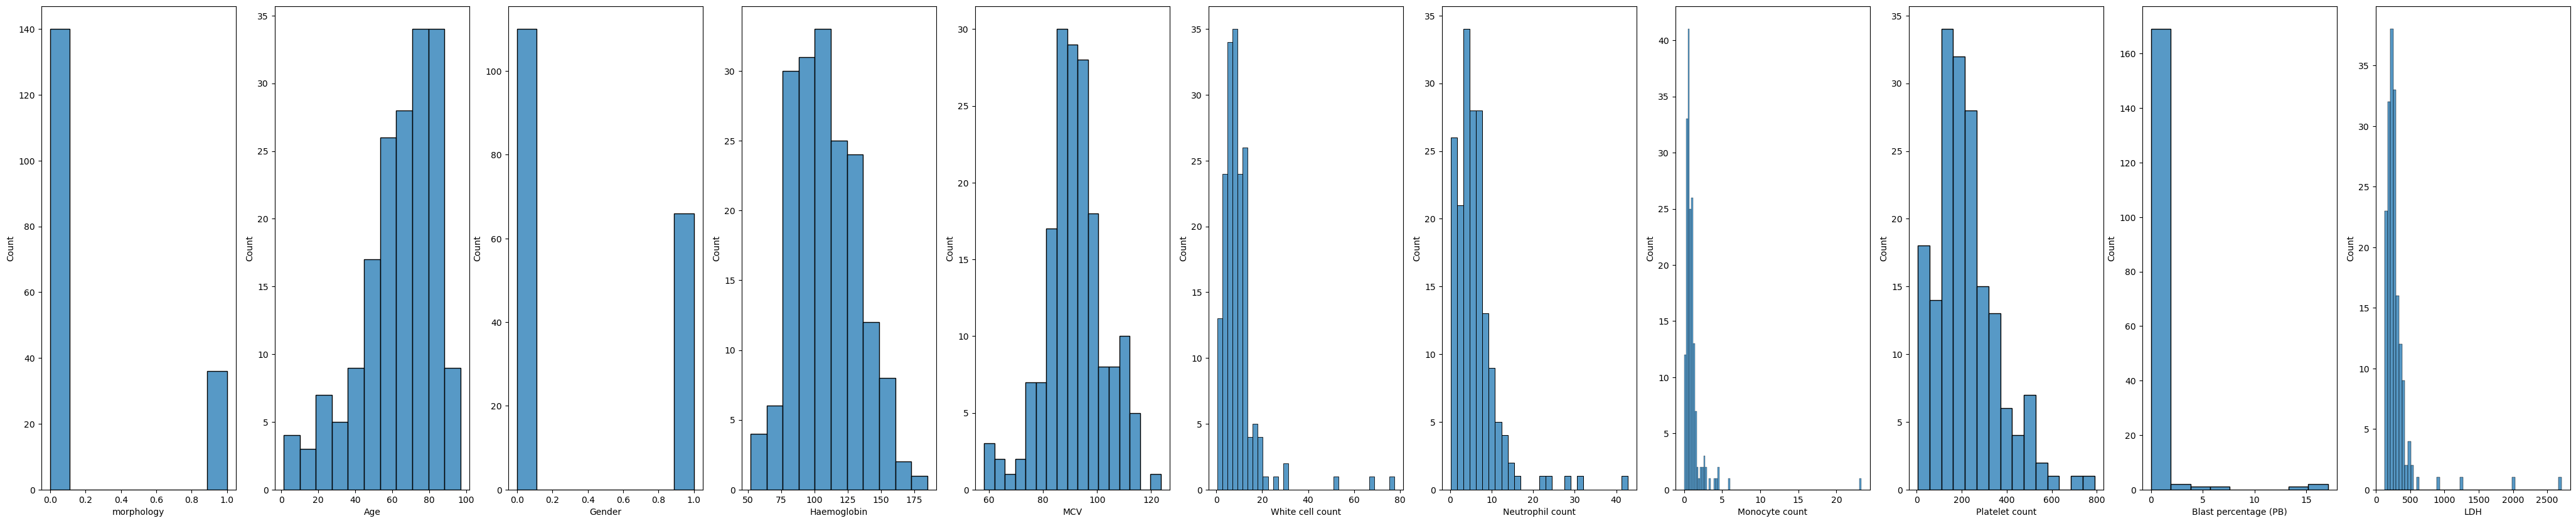

In [92]:
fig, axs = plt.subplots(1,11, figsize=(52, 10))
for i, ax in enumerate(axs):
    key = list(merged_df.keys())[2+i]
    sns.histplot(merged_df[key], ax=ax)
    # ax.set(xlabel=key,  title=f'Distribution of {key}')
    # ax.legend()
# plt.show()
plt.savefig("clinical_variables_dist.png", 
            bbox_inches ="tight", 
            pad_inches = 1, )

In [145]:
def train_single_sklearn(x, y, num_class, seed, feature_names, booster):
    """
    Train a single xgb classifier
    """

    dmat = xgb.DMatrix(x, y, feature_names=feature_names)

    if num_class > 2:
        metric = 'mlogloss'
        objective = 'multi:softprob'
    elif num_class == 2:
        metric = 'logloss'
        objective = 'binary:logistic'
    else:
        raise RuntimeError(f'num_class = {num_class}, must be >= 2')

    # random_forest = True
    random_forest = False

    if random_forest:
        params = dict(
            objective=objective,
            eval_metric=metric,
            nthread=4,
            colsample_bynode=0.6,
            learning_rate=1,
            max_depth=5,
            num_parallel_tree=100,
            subsample=0.6,
        )

        model = xgb.train(params, dmat, num_boost_round=1)
    else:
        params = dict(
            booster=booster,
            objective=objective,
            eval_metric=metric,
            nthread=4,
        )
        if num_class > 2:
            params['num_class'] = num_class

        xgb_cv_params = dict(
            metrics=metric,
            num_boost_round=200,
            early_stopping_rounds=10,
            stratified=True,
            nfold=10,
            seed=seed,
        )

        # find best num_boost_rounds for the optimal parameters
        # cv = xgb.cv(params, dmat, **xgb_cv_params)
        # num_boost_round = cv[f'test-{metric}-mean'].idxmin()

        # model = xgb.train(params, dmat, num_boost_round=num_boost_round)
        # params['num_boost_round'] = num_boost_round
        model = xgb.XGBClassifier(**params, importance_type='gain', validate_parameters=True)
        df_x = pd.DataFrame(x)
        df_x.columns = feature_names
        model.fit(df_x, y)

    return model, params


/tmp/ipykernel_1330888/3693889157.py:13: FutureWarning: this method is deprecated in favour of `Styler.format(precision=..)`
  corr.style.background_gradient(cmap='coolwarm').set_precision(2)


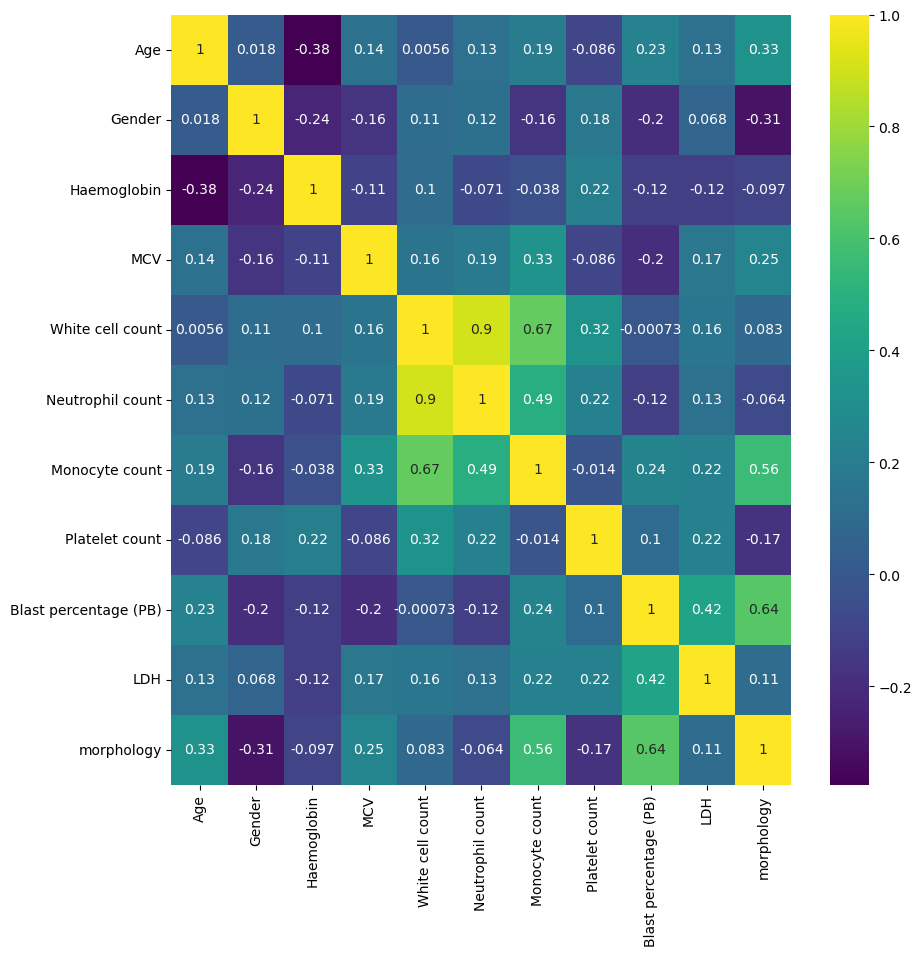

In [265]:
# dataset correlation

import copy
copied_df = copy.deepcopy(merged_df)
# copied_df = copied_df[['Age', 'Gender', 'Haemoglobin',
#      'MCV', 'White cell count', 'Neutrophil count', 'Monocyte count',
#      'Platelet count', 'Blast percentage (PB)', 'LDH', 'morphology'
# ]]

copied_df = copied_df[copied_df['set4'] == 'test'][['Age', 'Gender', 'Haemoglobin',
    'MCV', 'White cell count', 'Neutrophil count', 'Monocyte count',
    'Platelet count', 'Blast percentage (PB)', 'LDH', 'morphology'
]]
corr = copied_df.corr()
corr.style.background_gradient(cmap='coolwarm').set_precision(2)

fig, ax = plt.subplots(1,1, figsize=(10, 10))
ax = sns.heatmap(corr, 
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values,
            annot=True, cmap='viridis')
# plt.savefig('clinical_variables_correlation.jpg')

In [187]:
feature_columns = ['Age', 'Gender', 'Haemoglobin',
     'MCV', 'White cell count', 'Neutrophil count', 'Monocyte count',
     'Platelet count', 'Blast percentage (PB)', 'LDH'
]
target_column = 'morphology'
booster = 'gbtree'

for i in range(5):
     set_col = f'set{i}'
     x_values = merged_df[merged_df[set_col] == 'train'][feature_columns].values
     y_values = merged_df[merged_df[set_col] == 'train'][target_column].values  
     model, params = train_single_sklearn(x_values, y_values, num_class=2, seed=123, feature_names=feature_columns, booster=booster)
     X_test = merged_df[merged_df[set_col] == 'test'][feature_columns].values
     y_test = merged_df[merged_df[set_col] == 'test'][target_column].values
     # if booster == 'gbtree':
     #      preds = model.predict(X_test, iteration_range=(0, model.best_iteration + 1))
     # else:
     preds = model.predict(X_test)
     preds = preds.astype(int)
     print(y_test, preds)
     accuracy= accuracy_score(y_test, preds)
     print(f'Fold {i}: Accuracy of the model is:', accuracy*100)
     
     print(model.get_params())
     model._Booster.__del__()
     del model    
     import gc
     gc.collect()
     # break



[0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] [0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Fold 0: Accuracy of the model is: 100.0
{'objective': 'binary:logistic', 'base_score': None, 'booster': 'gbtree', 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': 'gain', 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight':

[0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] [0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Fold 0: Accuracy of the model is: 100.0 AUC: 1.0
[0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] [0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Fold 1: Accuracy of the model is: 82.85714285714286 AUC: 0.9074074074074074
[0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] [0 0 0 1 1 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Fold 2: Accuracy of the model is: 88.57142857142857 AUC: 0.9145299145299146
[0 0 1 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] [0 0 1 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Fold 3: Accuracy of the model is: 97.14285714285714 AUC: 0.9933333333333333
[1 0 1 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] [0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Fol

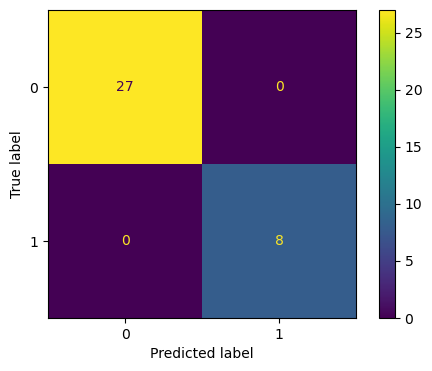

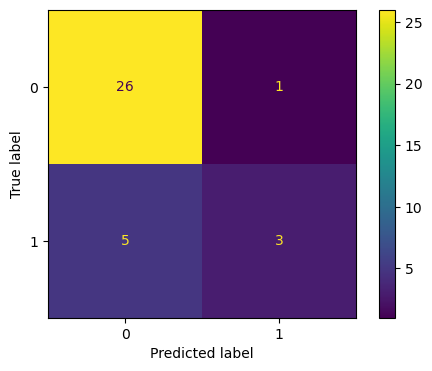

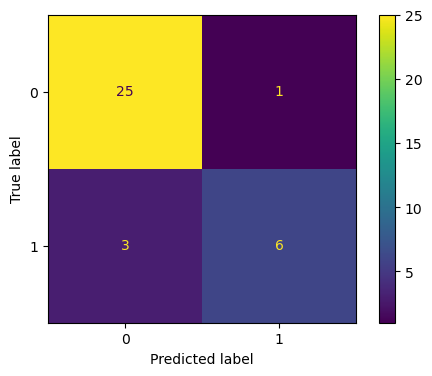

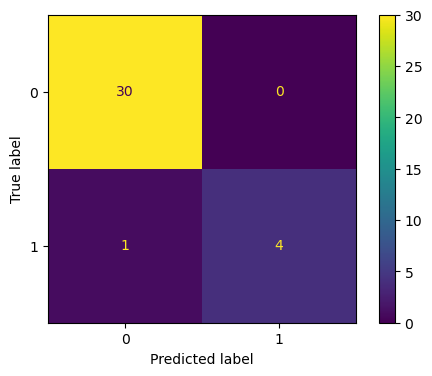

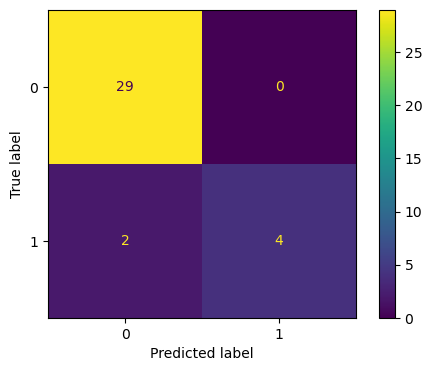

In [233]:
# https://www.kaggle.com/code/sn3fru/the-simple-xgboost-application-with-auc-89
# xgboost

feature_columns = ['Age', 'Gender', 'Haemoglobin',
    'MCV', 'White cell count', 'Neutrophil count', 'Monocyte count',
    'Platelet count', 'Blast percentage (PB)', 'LDH'
]
target_column = 'morphology'
booster = 'gbtree'

for i in range(5):
    set_col = f'set{i}'
    X_train = merged_df[merged_df[set_col] == 'train'][feature_columns]#.values
    y_train = merged_df[merged_df[set_col] == 'train'][target_column]#.values
    X_test = merged_df[merged_df[set_col] == 'test'][feature_columns]#.values
    y_test = merged_df[merged_df[set_col] == 'test'][target_column]#.values
    
    
    n=200
    params = {
        'objective': 'binary:logistic',
        # 'max_depth': 100,
        # 'learning_rate': 0.1,
        'eval_metric': 'logloss',
        'nthread': 4,
        'booster': 'gbtree',
        # 'n_estimators':100,
        # 'alpha': 10,
    }
    
    # xgb_train = xgb.DMatrix(X_train.values, y_train.values, feature_names=feature_columns)
    # model = xgb.train(params=params, dtrain=xgb_train, num_boost_round=n)
    # xgb_test = xgb.DMatrix(X_test.values, y_test.values, feature_names=feature_columns)
    # preds = model.predict(xgb_test)
    
    # instantiate the classifier 
    model = xgb.XGBClassifier(**params, importance_type='gain', validate_parameters=True)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    preds_prob = model.predict_proba(X_test)
    # print(np.around(preds_prob,3))
    preds = preds_prob.argmax(axis=1)#preds.astype(int)
    
    print(y_test.values, preds)
    # print(model.get_params())
    
    auc = metrics.roc_auc_score(y_test, preds_prob[:,1])
    accuracy= accuracy_score(y_test.values, preds)
    print(f'Fold {i}: Accuracy of the model is: {accuracy*100} AUC: {auc}')
    
    # model._Booster.__del__()
    # del model    
    # import gc
    # gc.collect()
    # break
    
    output_dir = f'./models/clinical_variable_fold_{i}'
    if not os.path.exists(output_dir):
        os.makedirs(output_dir, exist_ok=True)
    matrix = metrics.confusion_matrix(y_test.values, preds)
    disp = metrics.ConfusionMatrixDisplay(confusion_matrix=matrix) 
    disp.plot().figure_.savefig(os.path.join(output_dir, 'conf_mat.jpg'))
    # plt.show()
    
    np.savez_compressed(os.path.join(output_dir, 'patient_level_results'),
        labels=y_test.values, 
        preds=preds,
        logits=preds_prob,
        patient_ids=merged_df[merged_df[set_col] == 'test']['patient_id'].values
    )
    

In [ ]:
{'objective': 'binary:logistic', 'base_score': None, 'booster': 'gbtree', 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 
'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 
'gamma': None, 'grow_policy': None, 'importance_type': 'gain', 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 
'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': None, 'monotone_constraints': None, 
'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 
'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': True, 'verbosity': None, 'nthread': 4}

{'objective': 'binary:logistic', 'base_score': None, 'booster': 'gbtree', 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 
'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 
'gamma': None, 'grow_policy': None, 'importance_type': 'gain', 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 
'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 100, 'max_leaves': None, 'min_child_weight': None, 'missing': None, 'monotone_constraints': None, 
'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 
'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': True, 'verbosity': None, 'nthread': 4, 'alpha': 10}

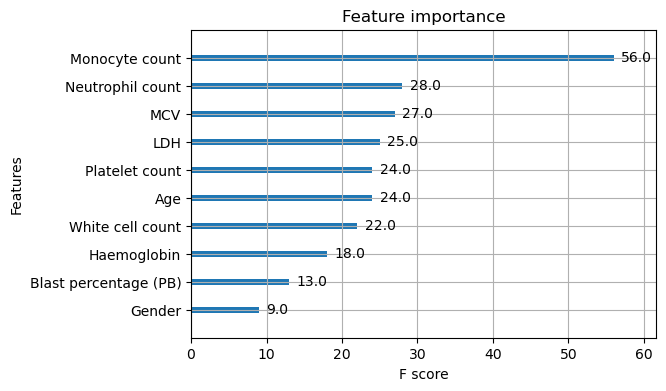

In [196]:
# feature importance
xgb.plot_importance(model)
plt.rcParams['figure.figsize'] = [6, 4]
plt.show()